# Notebook 1 — Étude exploratoire du dataset béton

## Objectif général

Ce notebook réalise une **étude exploratoire des données** issues de la fusion entre `concrete.csv` et `Formulations.csv`.

L'objectif n'est pas encore de construire un modèle de prédiction.  
L'objectif est d'abord de **comprendre les données comme un ingénieur civil** :

- quelles sont les plages de dosage utilisées ;
- quelles formulations semblent cohérentes ou atypiques ;
- quelles variables influencent le plus la résistance à la compression ;
- si le dataset est suffisamment riche pour préparer ensuite un modèle de prédiction ;
- si les données peuvent aider à choisir une composition adaptée à une performance demandée par un client.

⚠️ Dans ce notebook, on **ne crée pas de nouvelles variables**.  
On travaille uniquement avec les colonnes déjà présentes dans le CSV fusionné.

## 1. Importation des bibliothèques

### Utilité dans le projet

Cette étape prépare les outils nécessaires pour analyser le dataset :

- `pandas` : manipuler le tableau de données ;
- `numpy` : réaliser certains calculs numériques ;
- `matplotlib` : produire les graphiques ;
- quelques options d'affichage pour rendre les résultats plus lisibles.

Dans un projet de génie civil, cette étape correspond à la préparation de la feuille d'analyse avant d'interpréter les essais de laboratoire.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Améliorer la lisibilité des tableaux affichés
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)

# Option graphique générale
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

## 2. Chargement du dataset fusionné

### Utilité dans le projet

On charge le fichier CSV final obtenu après fusion des deux datasets.  
Ce fichier représente notre base de travail pour comprendre les formulations de béton disponibles.

Chaque ligne correspond à une formulation de béton.  
Chaque colonne représente soit un composant du béton, soit une propriété mesurée.

Dans la suite du projet, ce même dataset servira à entraîner des modèles capables de prédire la résistance.

In [2]:
# Chemin du fichier CSV fusionné
# Le fichier doit se trouver dans le même dossier que ce notebook.
dataset_path = Path("dataset_concrete_formulations_final.csv")

df = pd.read_csv(dataset_path)

print("Dataset chargé avec succès.")
print("Dimensions du dataset :", df.shape)
display(df.head())

Dataset chargé avec succès.
Dimensions du dataset : (302, 9)


,Ciment,Eau,Superplastifiant,Granulats_grossiers,Granulats_fins,G/S,E/C,Age,Resistance
0,540.0,162.0,2.5,1040.0,676.0,1.538,0.30,28,79.99
1,540.0,162.0,2.5,1055.0,676.0,1.561,0.30,28,61.89
2,475.0,228.0,0.0,932.0,594.0,1.569,0.48,28,39.29
3,380.0,228.0,0.0,932.0,670.0,1.391,0.60,90,52.91
4,475.0,228.0,0.0,932.0,594.0,1.569,0.48,180,42.62


## 3. Description des colonnes

### Utilité dans le projet

Avant d'analyser les chiffres, il faut comprendre ce que signifie chaque variable.

Dans le béton, la résistance finale dépend fortement :

- du dosage en ciment ;
- de la quantité d'eau ;
- du rapport eau/ciment `E/C` ;
- des granulats ;
- de l'âge du béton au moment de l'essai ;
- de l'utilisation ou non d'un superplastifiant.

Cette étape sert donc à relier les colonnes du dataset à leur signification physique.

In [4]:
print("Liste des colonnes disponibles :")
display(df.dtypes.to_frame("Type"))

Liste des colonnes disponibles :


,Type
Ciment,float64
Eau,float64
Superplastifiant,float64
Granulats_grossiers,float64
Granulats_fins,float64
G/S,float64
E/C,float64
Age,int64
Resistance,float64


### Dictionnaire métier des variables

| Variable | Signification métier |
|---|---|
| `Ciment` | Quantité de ciment utilisée dans la formulation |
| `Eau` | Quantité d'eau introduite dans le mélange |
| `Superplastifiant` | Adjuvant permettant d'améliorer l'ouvrabilité ou de réduire l'eau |
| `Granulats_grossiers` | Gravier ou gros granulats |
| `Granulats_fins` | Sable ou granulats fins |
| `G/S` | Rapport granulats grossiers / granulats fins, déjà présent dans le fichier |
| `E/C` | Rapport eau / ciment, déjà présent dans le fichier |
| `Age` | Âge du béton au moment de l'essai |
| `Resistance` | Résistance à la compression mesurée |

La variable cible principale pour la suite du projet sera `Resistance`.

## 4. Vérification de la qualité des données

### Utilité dans le projet

Un modèle de prédiction ne peut être fiable que si les données sont propres.

Dans un contexte de laboratoire ou de centrale à béton, une donnée incorrecte peut provenir de :

- une erreur de saisie ;
- une unité mal convertie ;
- une mesure manquante ;
- une formulation dupliquée ;
- une valeur impossible physiquement.

Cette section vérifie ces problèmes avant toute interprétation.

In [5]:
print("Nombre de valeurs manquantes par colonne :")
missing = df.isna().sum().to_frame("Valeurs manquantes")
missing["Pourcentage (%)"] = (df.isna().mean() * 100).round(2)
display(missing)

print("\nNombre de lignes dupliquées :", df.duplicated().sum())

Nombre de valeurs manquantes par colonne :


,Valeurs manquantes,Pourcentage (%)
Ciment,0,0.0
Eau,0,0.0
Superplastifiant,0,0.0
Granulats_grossiers,0,0.0
Granulats_fins,0,0.0
G/S,0,0.0
E/C,0,0.0
Age,0,0.0
Resistance,0,0.0



Nombre de lignes dupliquées : 1


## 5. Vérification des valeurs nulles

### Utilité dans le projet

Dans une formulation de béton, certaines valeurs nulles peuvent être normales :

- `Superplastifiant = 0` signifie que la formulation n'utilise pas d'adjuvant ;
- certaines additions peuvent être absentes si elles existent dans le dataset.

Mais une valeur nulle dans `Ciment`, `Eau`, `Age` ou `Resistance` serait beaucoup plus problématique.

Cette vérification aide à distinguer les zéros normaux des zéros suspects.

,Nombre de zéros,Pourcentage de zéros (%)
Ciment,0,0.00
Eau,0,0.00
Superplastifiant,247,81.79
Granulats_grossiers,0,0.00
Granulats_fins,0,0.00
G/S,0,0.00
E/C,0,0.00
Age,0,0.00
Resistance,0,0.00


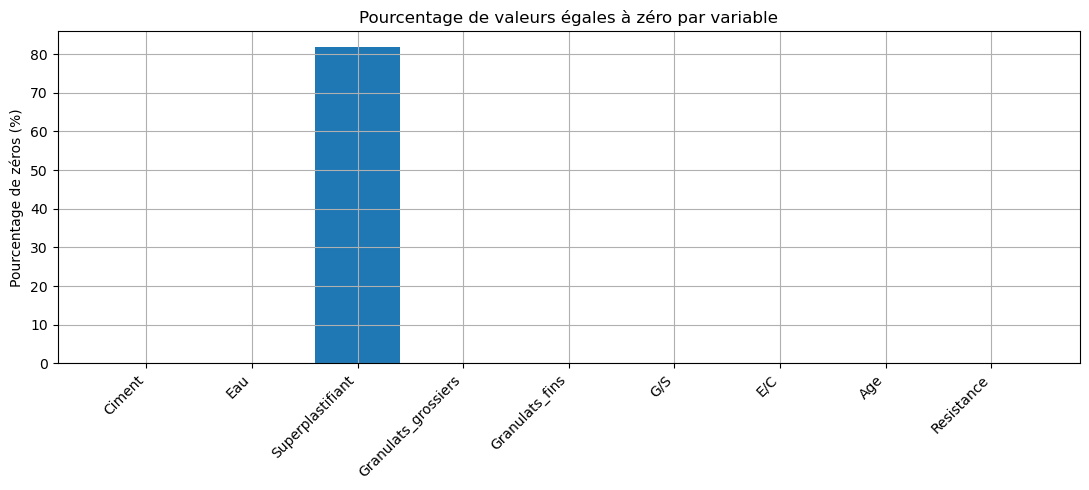

In [6]:
zero_stats = pd.DataFrame({
    "Nombre de zéros": (df == 0).sum(),
    "Pourcentage de zéros (%)": ((df == 0).mean() * 100).round(2)
})

display(zero_stats)

# Graphique du pourcentage de zéros par variable
plt.figure(figsize=(11, 5))
plt.bar(zero_stats.index, zero_stats["Pourcentage de zéros (%)"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Pourcentage de zéros (%)")
plt.title("Pourcentage de valeurs égales à zéro par variable")
plt.tight_layout()
plt.show()

## 6. Statistiques descriptives globales

### Utilité dans le projet

Les statistiques descriptives donnent une première vision des plages de variation :

- minimum et maximum : limites observées dans les formulations ;
- moyenne : formulation moyenne ;
- écart-type : dispersion des valeurs ;
- quartiles : répartition des observations.

Pour un ingénieur civil, cette étape permet de vérifier si les dosages sont réalistes et si le dataset couvre plusieurs types de béton.

In [7]:
desc = df.describe().T
desc["coefficient_variation_%"] = (desc["std"] / desc["mean"] * 100).round(2)
display(desc)

,count,mean,std,min,25%,50%,75%,max,coefficient_variation_%
Ciment,302.0,366.914,81.347,200.000,310.000,350.000,400.000,540.000,22.17
Eau,302.0,202.319,77.200,140.000,184.250,191.000,193.000,664.000,38.16
Superplastifiant,302.0,1.082,3.918,0.000,0.000,0.000,0.000,28.200,362.14
Granulats_grossiers,302.0,1026.481,150.708,420.000,968.000,1031.500,1118.800,1375.000,14.68
Granulats_fins,302.0,744.634,97.635,420.000,668.000,764.000,812.000,945.000,13.11
G/S,302.0,1.414,0.349,0.557,1.197,1.358,1.615,3.119,24.66
E/C,302.0,0.578,0.239,0.267,0.482,0.546,0.627,1.897,41.44
Age,302.0,49.242,78.152,1.000,7.000,28.000,28.000,365.000,158.71
Resistance,302.0,31.506,14.616,6.270,21.078,29.990,39.083,79.990,46.39


### Comment lire ces statistiques ?

Quelques questions importantes :

- La plage de `Ciment` couvre-t-elle des bétons faiblement et fortement dosés ?
- Le rapport `E/C` est-il dans des valeurs raisonnables ?
- L'âge `Age` contient-il surtout des essais à 28 jours ou aussi d'autres âges ?
- La variable `Resistance` couvre-t-elle suffisamment de niveaux de résistance ?

Plus la plage de valeurs est large, plus le futur modèle aura la possibilité d'apprendre différents comportements.

## 7. Distribution des variables numériques

### Utilité dans le projet

Les histogrammes montrent comment les valeurs sont réparties.

Ils permettent de répondre à des questions métier :

- Les formulations sont-elles concentrées autour d'un seul dosage ?
- Le dataset contient-il plusieurs familles de béton ?
- Certaines valeurs sont-elles très rares ?
- La résistance est-elle équilibrée entre faibles, moyennes et fortes résistances ?

Un dataset trop concentré peut donner un modèle qui prédit bien uniquement une petite famille de bétons.

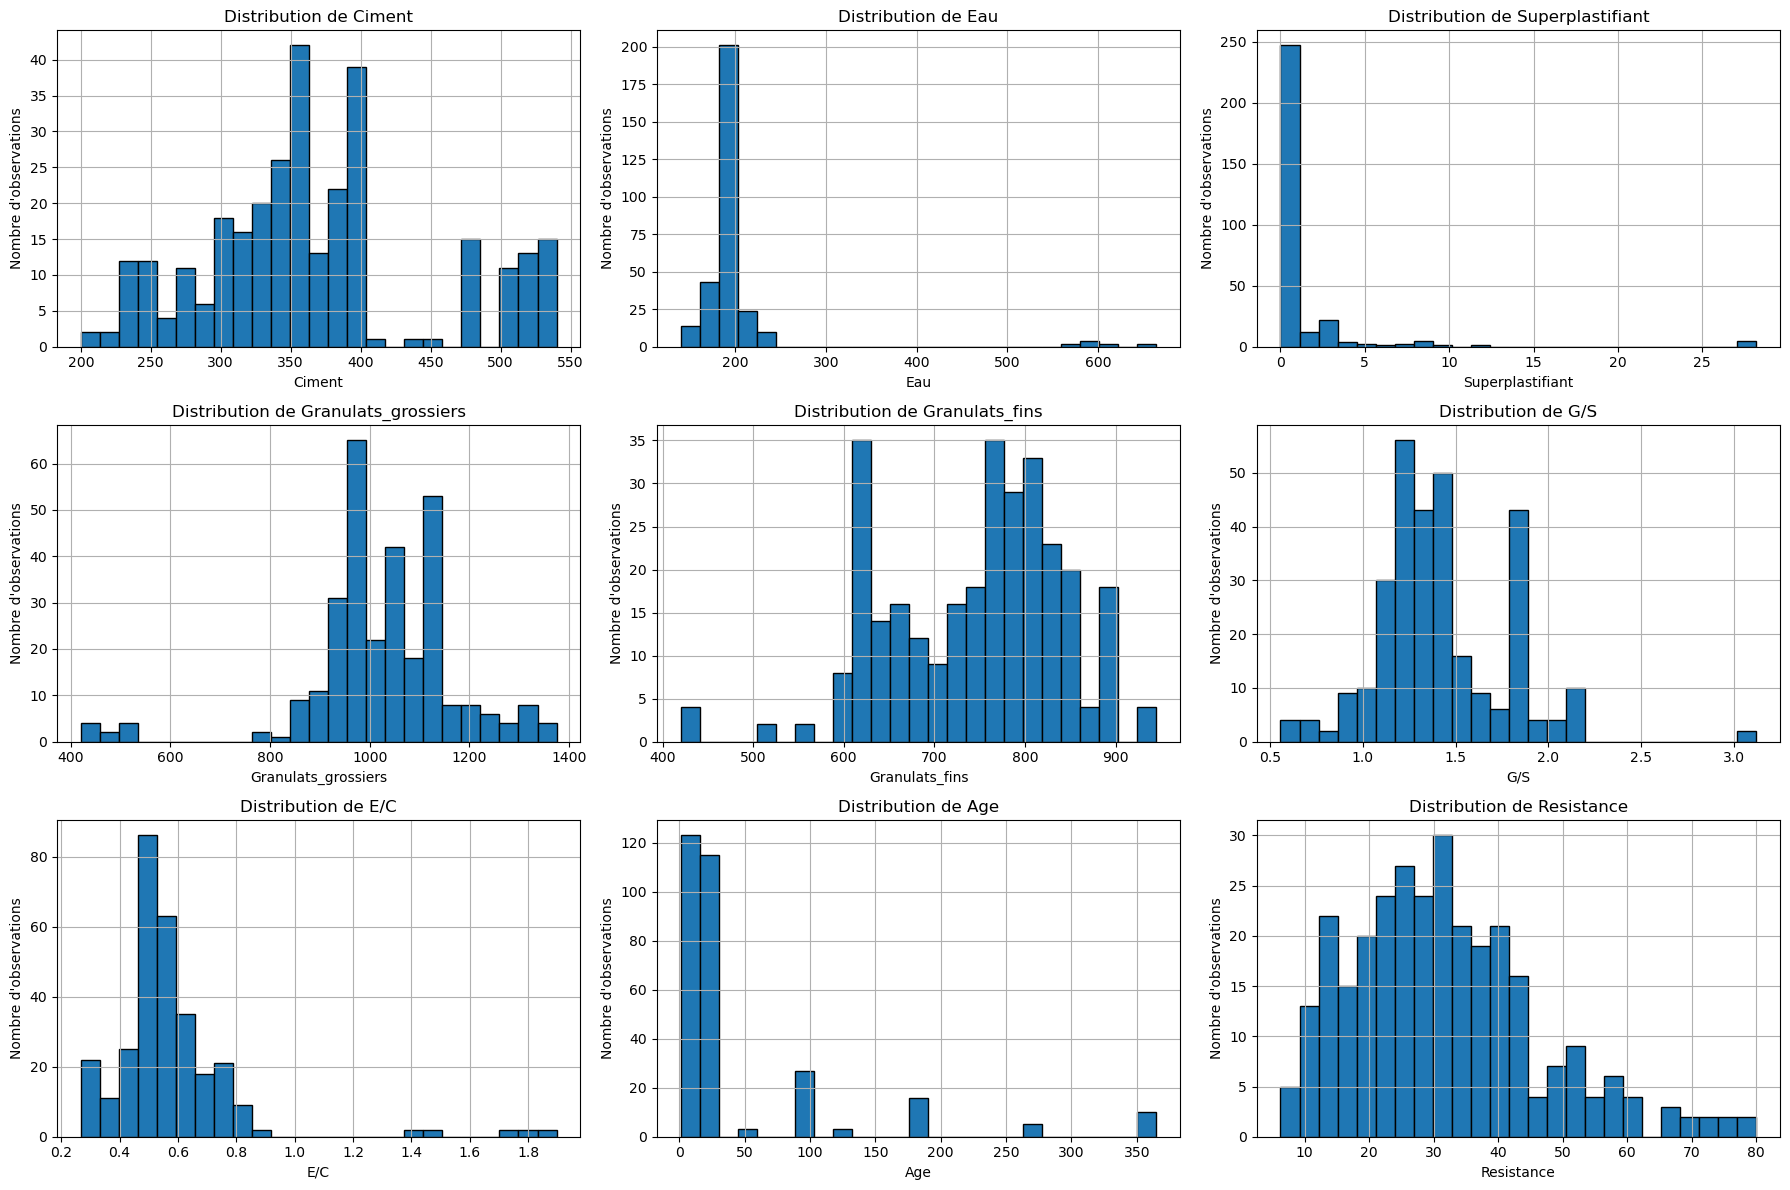

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=25, edgecolor="black")
    axes[i].set_title(f"Distribution de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Nombre d'observations")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 8. Analyse des valeurs extrêmes par boxplots

### Utilité dans le projet

Les boxplots permettent d'identifier les valeurs très éloignées du reste des données.

Dans notre cas, une valeur extrême n'est pas forcément une erreur.  
Elle peut représenter :

- un béton très fortement dosé en ciment ;
- un béton très fluide avec beaucoup d'eau ;
- une formulation spéciale ;
- un essai à un âge inhabituel.

Mais ces valeurs doivent être repérées, car elles peuvent influencer fortement les modèles de Machine Learning.

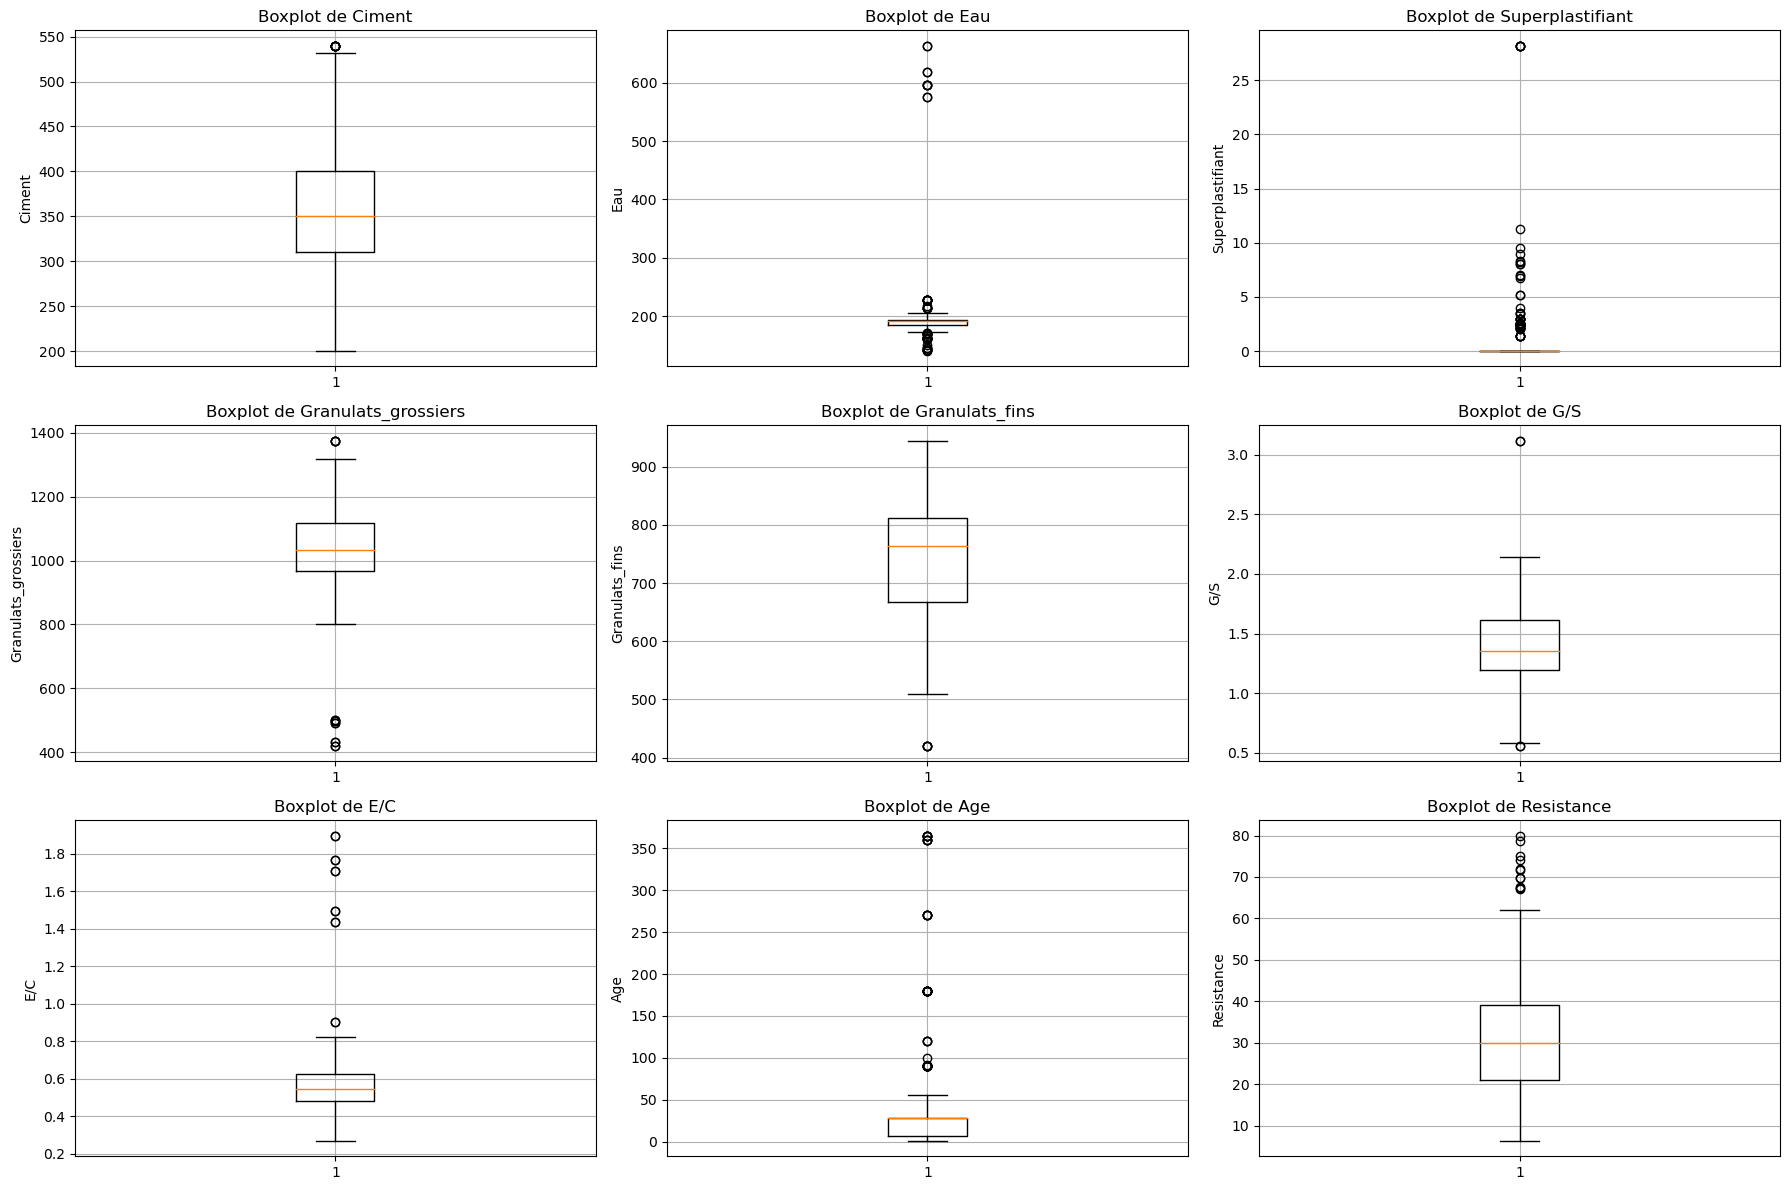

In [9]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(f"Boxplot de {col}")
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 9. Matrice de corrélation

### Utilité dans le projet

La corrélation mesure la relation linéaire entre deux variables.

Pour notre projet, elle aide à identifier :

- les variables qui semblent liées à la résistance ;
- les variables qui évoluent ensemble ;
- les redondances possibles entre colonnes.

Attention : une corrélation n'est pas une preuve de causalité.  
Elle donne seulement un indice statistique qui doit être interprété avec le raisonnement du génie civil.

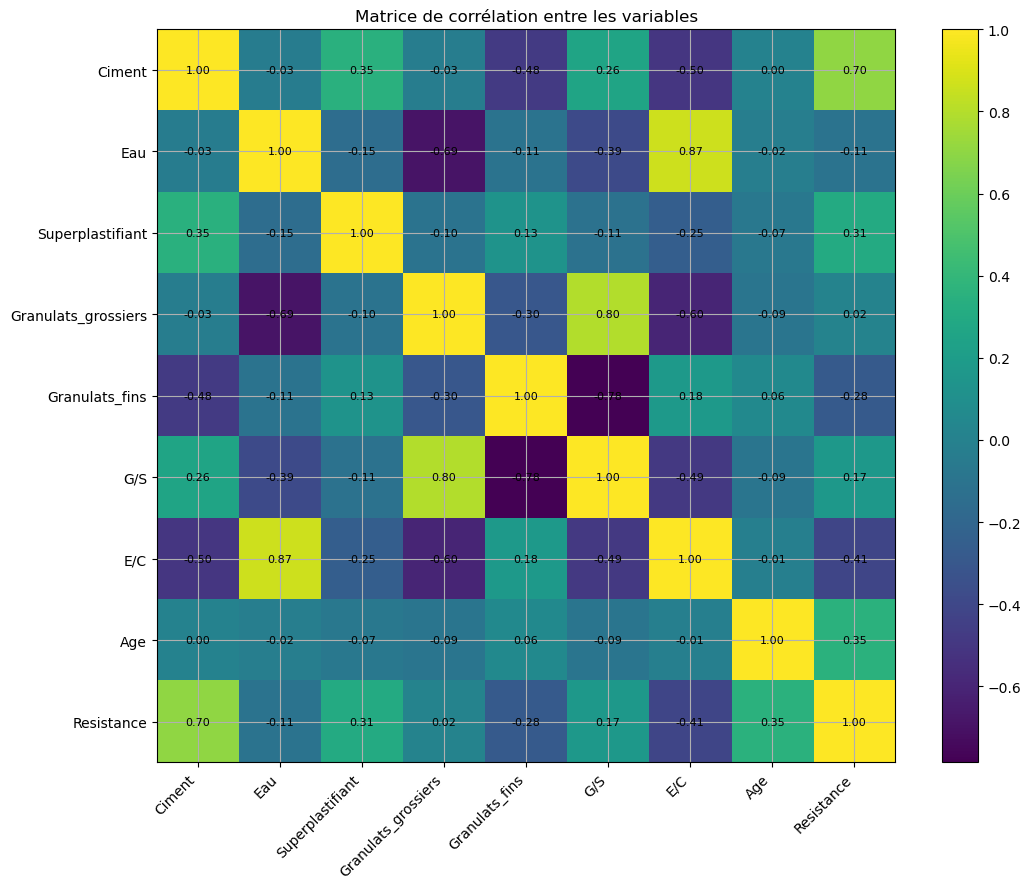

Corrélation des variables avec la résistance :


,Corrélation avec Resistance
Resistance,1.000
Ciment,0.703
Age,0.352
Superplastifiant,0.309
G/S,0.167
Granulats_grossiers,0.015
Eau,-0.108
Granulats_fins,-0.279
E/C,-0.409


In [10]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
ax.set_title("Matrice de corrélation entre les variables")

# Afficher les valeurs dans la matrice
for r in range(len(corr.index)):
    for c in range(len(corr.columns)):
        ax.text(c, r, f"{corr.iloc[r, c]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("Corrélation des variables avec la résistance :")
if "Resistance" in corr.columns:
    display(corr["Resistance"].sort_values(ascending=False).to_frame("Corrélation avec Resistance"))

## 10. Analyse métier de la résistance

### Question métier

**Quelles variables semblent influencer la résistance à la compression ?**

Cette question est centrale dans le projet.  
En pratique, un ingénieur civil cherche à comprendre comment modifier la formulation pour atteindre une résistance cible :

- augmenter le ciment ?
- réduire l'eau ?
- ajuster les granulats ?
- utiliser un superplastifiant ?
- attendre un âge de cure plus long ?

Les graphiques suivants ne construisent pas encore de modèle.  
Ils servent à visualiser les tendances.

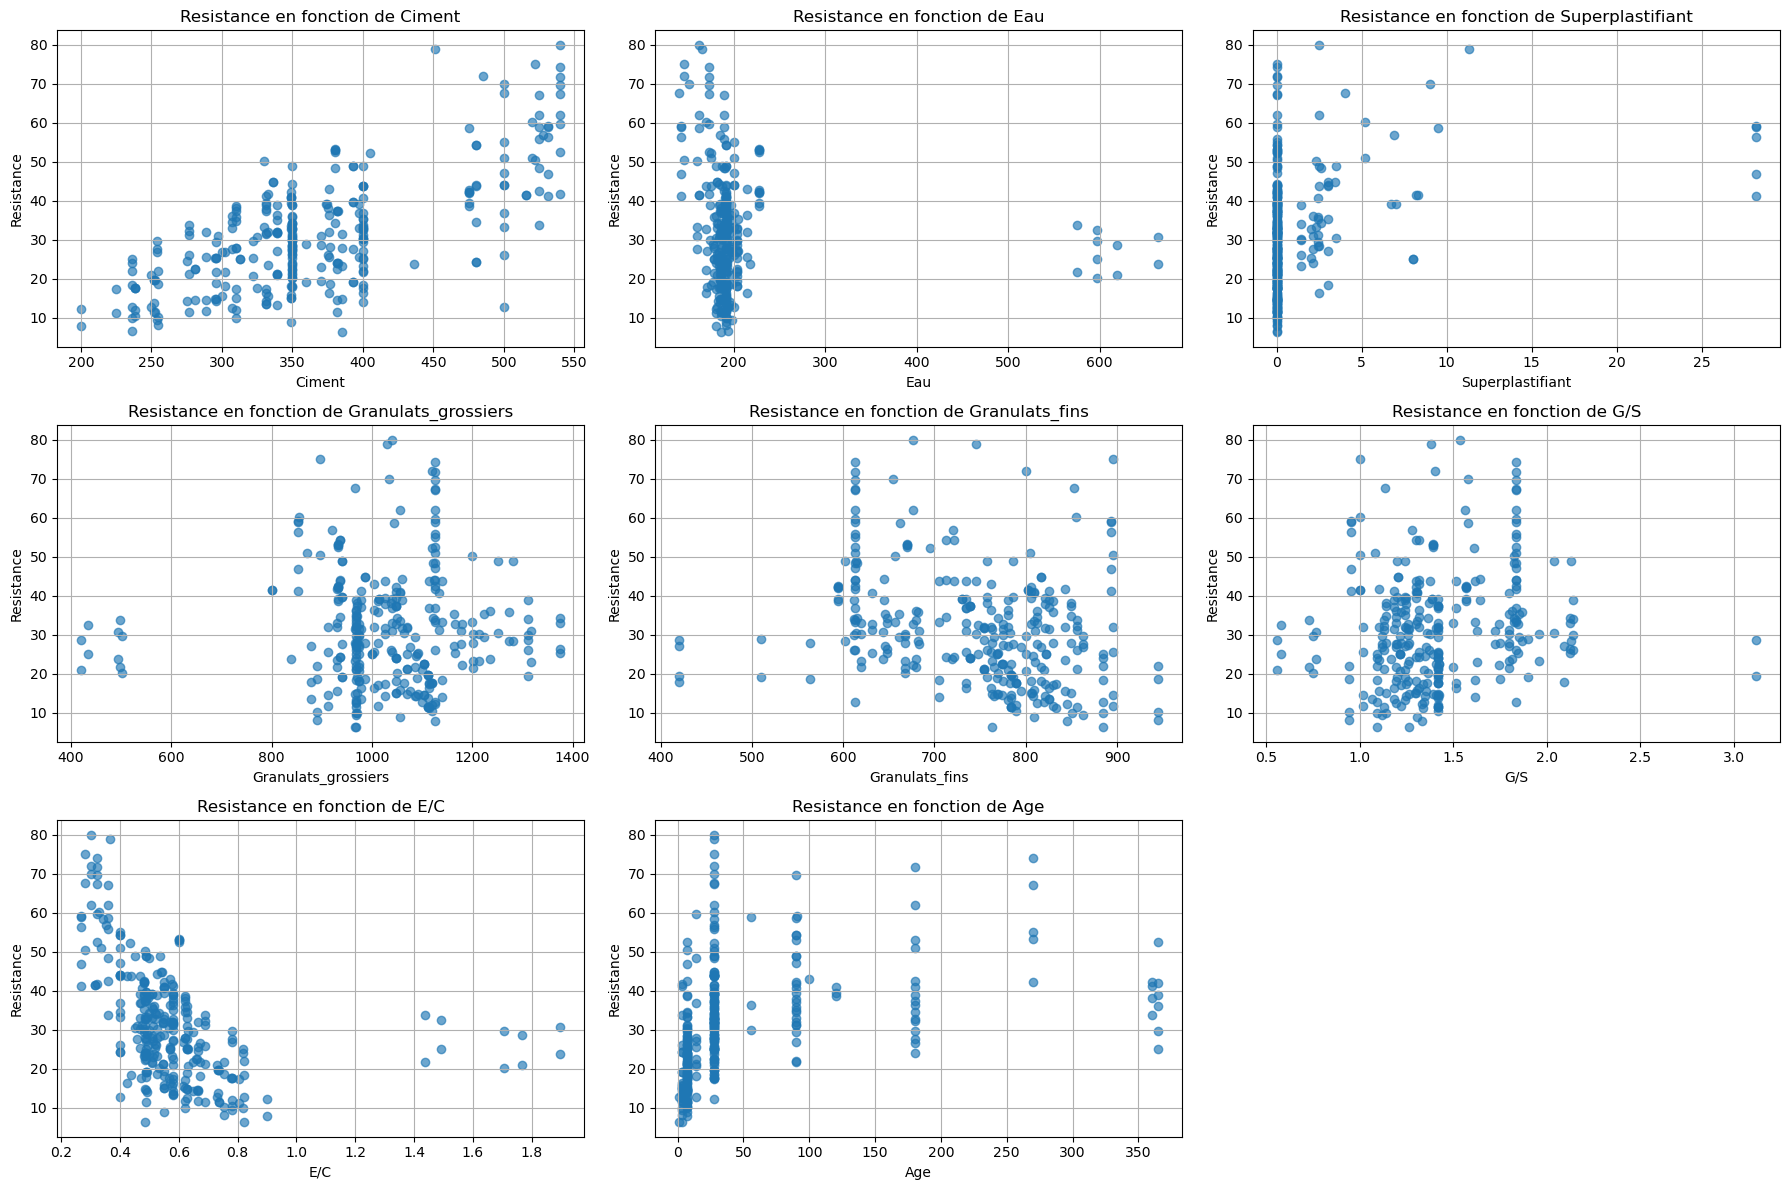

In [11]:
target = "Resistance"

if target in df.columns:
    explanatory_cols = [col for col in numeric_cols if col != target]

    n_cols = 3
    n_rows = int(np.ceil(len(explanatory_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(explanatory_cols):
        axes[i].scatter(df[col], df[target], alpha=0.65)
        axes[i].set_title(f"{target} en fonction de {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(target)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("La colonne Resistance n'existe pas dans le dataset.")

## 11. Focus sur les relations les plus importantes

### Utilité dans le projet

Certains paramètres sont particulièrement importants dans la technologie du béton :

- `E/C` : un rapport eau/ciment élevé diminue généralement la résistance ;
- `Ciment` : un dosage plus élevé peut améliorer la résistance, mais augmente le coût ;
- `Eau` : utile pour l'ouvrabilité, mais défavorable si elle est excessive ;
- `Age` : la résistance augmente généralement avec le temps ;
- `Superplastifiant` : permet d'améliorer l'ouvrabilité sans forcément augmenter l'eau.

Cette section met ces relations en évidence avec des graphiques plus lisibles.

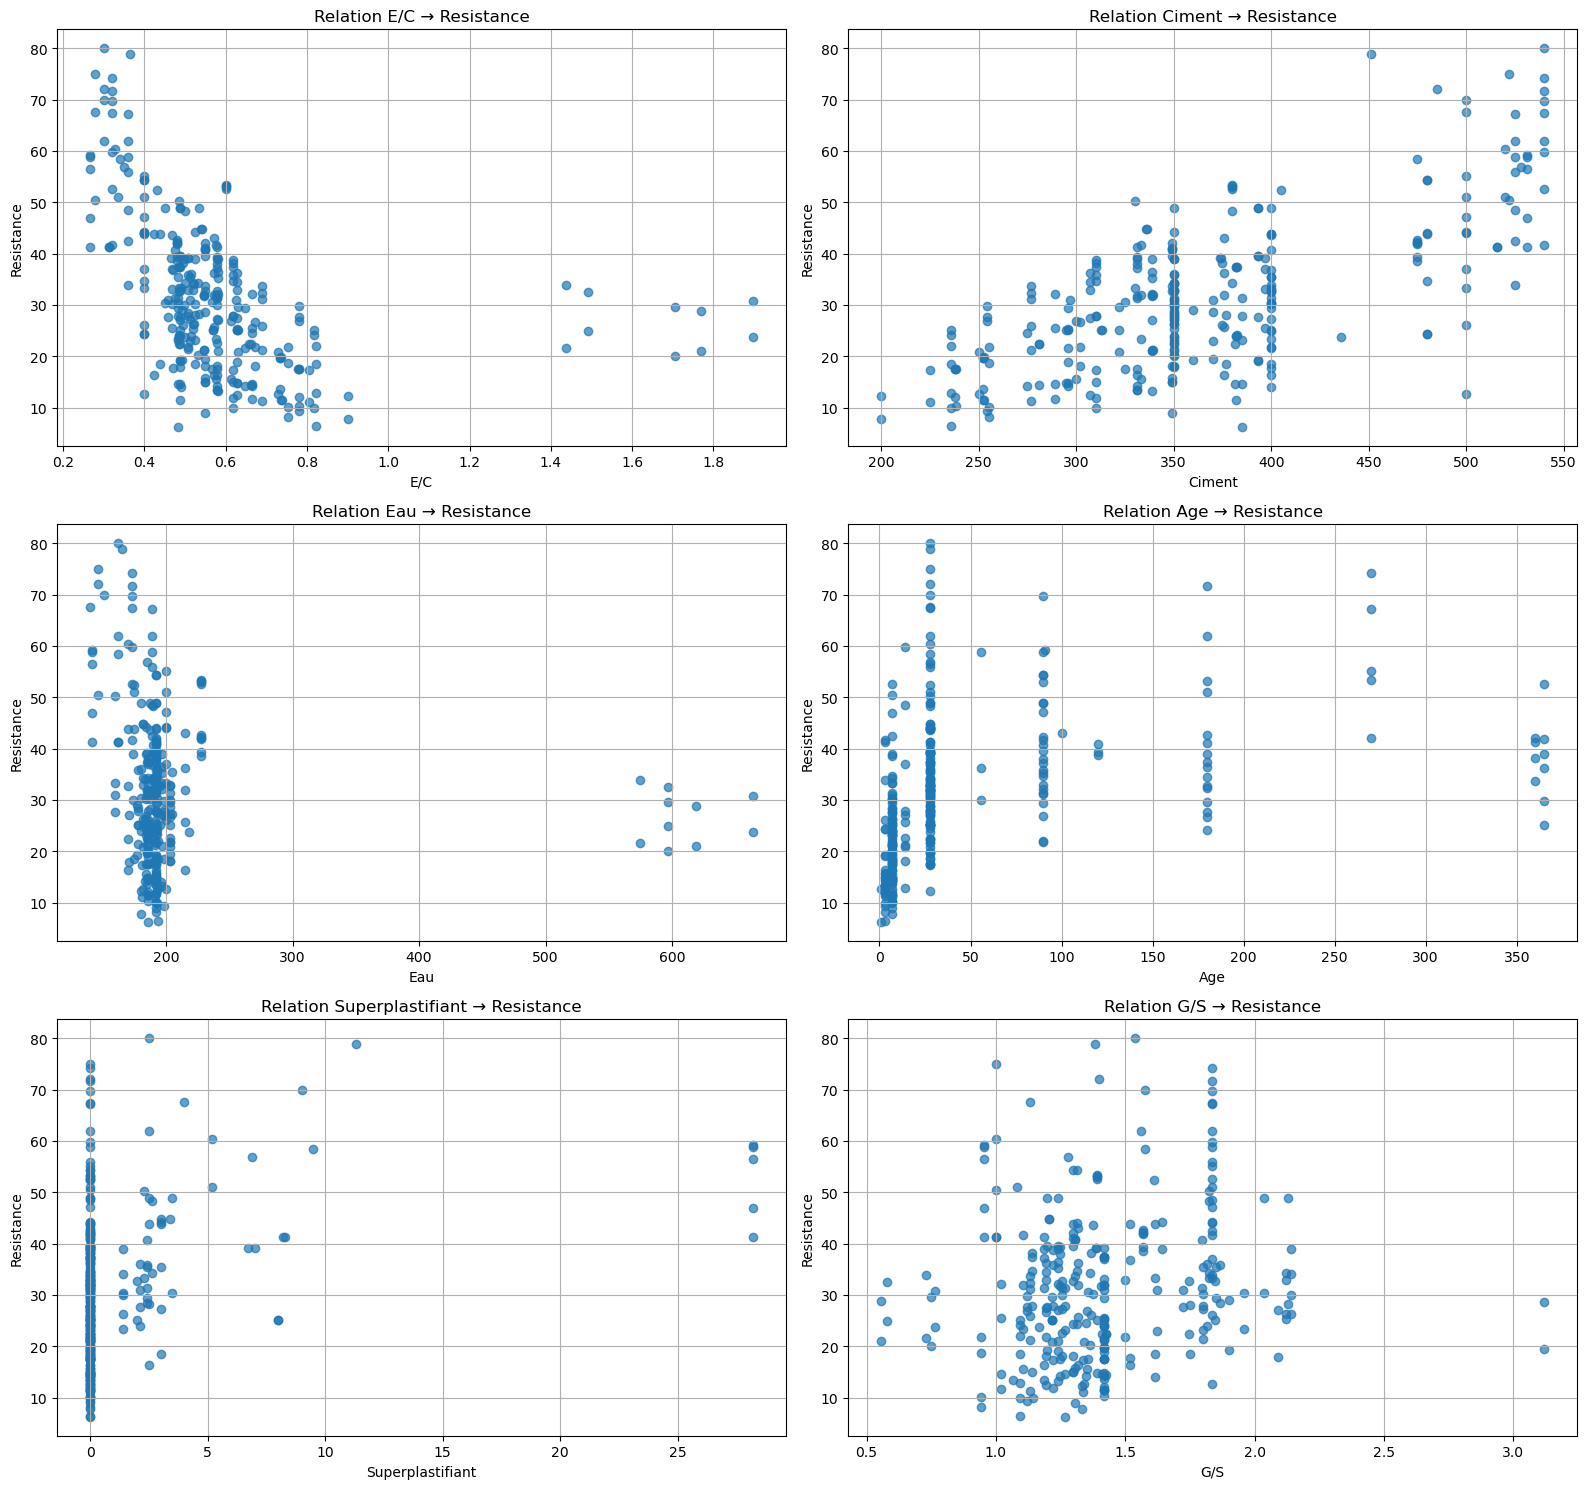

In [12]:
important_pairs = [
    ("E/C", "Resistance"),
    ("Ciment", "Resistance"),
    ("Eau", "Resistance"),
    ("Age", "Resistance"),
    ("Superplastifiant", "Resistance"),
    ("G/S", "Resistance"),
]

available_pairs = [(x, y) for x, y in important_pairs if x in df.columns and y in df.columns]

n_cols = 2
n_rows = int(np.ceil(len(available_pairs) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, (x, y) in enumerate(available_pairs):
    axes[i].scatter(df[x], df[y], alpha=0.7)
    axes[i].set_title(f"Relation {x} → {y}")
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 12. Analyse de l'effet de l'âge

### Question métier

**Comment la résistance évolue-t-elle selon l'âge du béton ?**

En génie civil, la résistance à 28 jours est souvent une référence importante.  
Mais les essais peuvent aussi être réalisés à 3, 7, 14, 56 ou 90 jours.

Cette analyse permet de vérifier si le dataset contient plusieurs âges d'essai et si la résistance augmente globalement avec l'âge.

,Age,count,mean,min,max,std
0,1,2,9.455,6.27,12.64,4.504
1,3,26,17.624,6.47,41.64,9.248
2,7,84,22.418,7.84,52.61,9.121
3,14,11,29.201,12.84,59.76,13.966
4,28,115,36.232,12.25,79.99,13.780
5,56,3,41.693,29.98,58.80,15.148
6,90,25,40.294,21.86,69.66,11.737
7,91,1,59.200,59.20,59.20,NaN
8,100,1,43.060,43.06,43.06,NaN
9,120,3,39.647,38.70,40.86,1.104


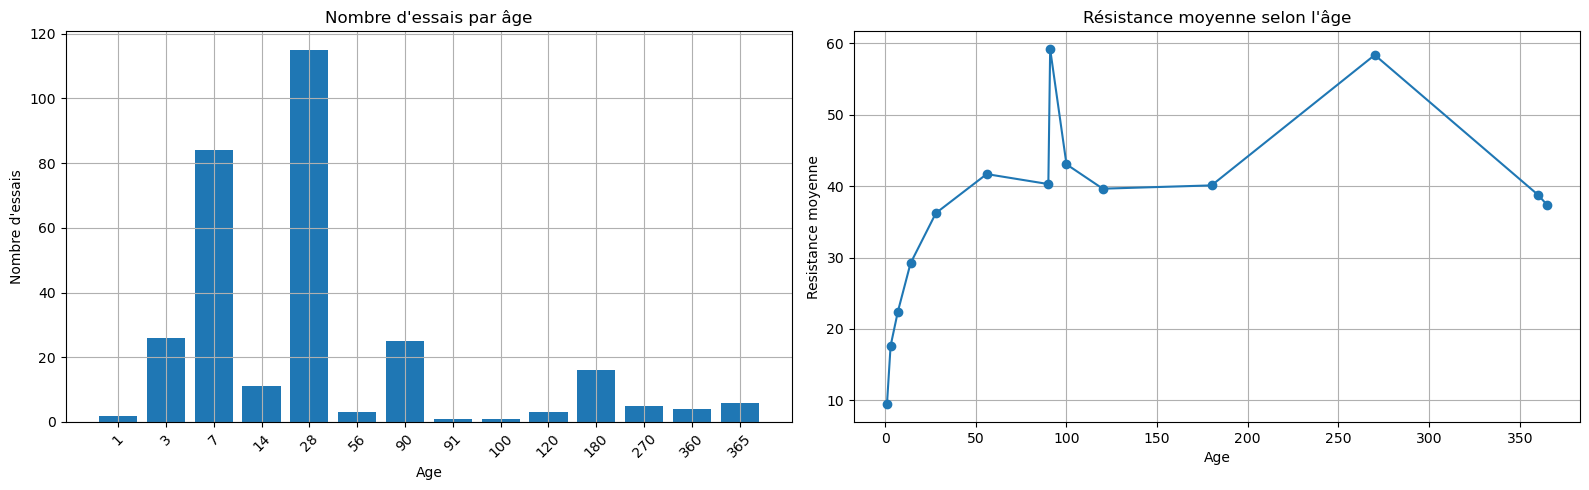

In [13]:
if "Age" in df.columns and "Resistance" in df.columns:
    age_stats = df.groupby("Age")["Resistance"].agg(["count", "mean", "min", "max", "std"]).reset_index()
    display(age_stats)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].bar(age_stats["Age"].astype(str), age_stats["count"])
    axes[0].set_title("Nombre d'essais par âge")
    axes[0].set_xlabel("Age")
    axes[0].set_ylabel("Nombre d'essais")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].plot(age_stats["Age"], age_stats["mean"], marker="o")
    axes[1].set_title("Résistance moyenne selon l'âge")
    axes[1].set_xlabel("Age")
    axes[1].set_ylabel("Resistance moyenne")

    plt.tight_layout()
    plt.show()

## 13. Analyse de l'effet du ciment

### Question métier

**L'augmentation du ciment améliore-t-elle toujours la résistance ?**

Le ciment est le composant liant principal.  
Cependant, son augmentation ne garantit pas toujours une augmentation proportionnelle de la résistance, car l'eau, l'âge, les granulats et l'adjuvant interviennent aussi.

Cette section permet d'observer la tendance globale sans encore isoler tous les effets.

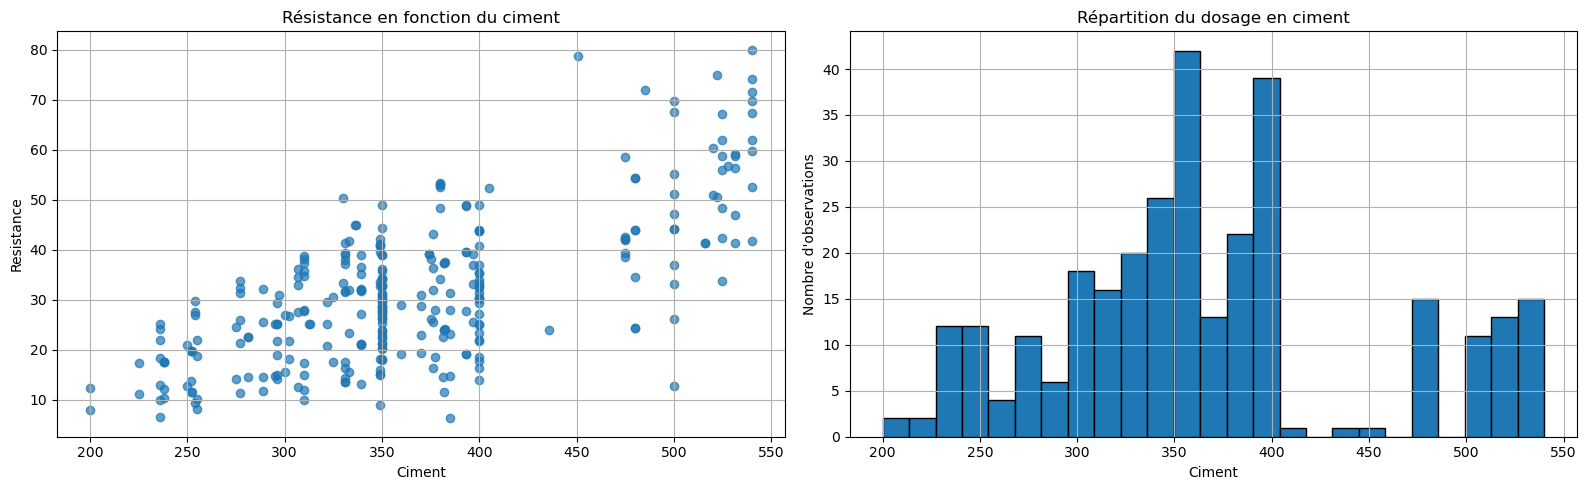

Corrélation Ciment / Resistance : 0.702920894251216


In [14]:
if "Ciment" in df.columns and "Resistance" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].scatter(df["Ciment"], df["Resistance"], alpha=0.7)
    axes[0].set_title("Résistance en fonction du ciment")
    axes[0].set_xlabel("Ciment")
    axes[0].set_ylabel("Resistance")

    axes[1].hist(df["Ciment"].dropna(), bins=25, edgecolor="black")
    axes[1].set_title("Répartition du dosage en ciment")
    axes[1].set_xlabel("Ciment")
    axes[1].set_ylabel("Nombre d'observations")

    plt.tight_layout()
    plt.show()

    print("Corrélation Ciment / Resistance :", df["Ciment"].corr(df["Resistance"]))

## 14. Analyse de l'effet de l'eau et du rapport E/C

### Question métier

**L'eau facilite la mise en place, mais que se passe-t-il pour la résistance ?**

En pratique :

- plus d'eau peut améliorer l'ouvrabilité ;
- trop d'eau peut créer plus de porosité après durcissement ;
- le rapport `E/C` est donc souvent un indicateur très important.

Cette section analyse séparément `Eau` et `E/C`, sans créer de nouvelle variable.

Corrélation Eau / Resistance : -0.10824592547902771
Corrélation E/C / Resistance : -0.408792683300684


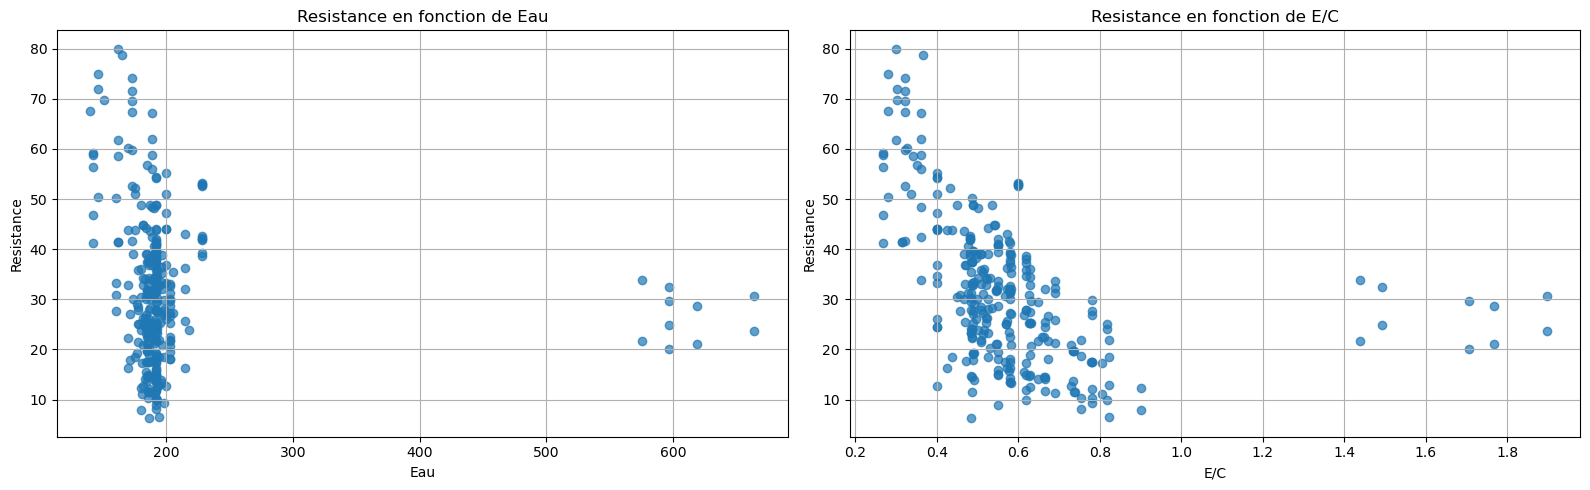

In [15]:
cols_to_plot = [col for col in ["Eau", "E/C"] if col in df.columns]

fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(8 * len(cols_to_plot), 5))
if len(cols_to_plot) == 1:
    axes = [axes]

for ax, col in zip(axes, cols_to_plot):
    ax.scatter(df[col], df["Resistance"], alpha=0.7)
    ax.set_title(f"Resistance en fonction de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Resistance")
    print(f"Corrélation {col} / Resistance :", df[col].corr(df["Resistance"]))

plt.tight_layout()
plt.show()

## 15. Analyse du superplastifiant

### Question métier

**Le superplastifiant permet-il d'améliorer les performances ?**

Le superplastifiant est important car il peut permettre :

- d'améliorer l'ouvrabilité ;
- de réduire la quantité d'eau ;
- d'obtenir une résistance plus élevée à ouvrabilité équivalente.

Dans ce dataset, on observe seulement la relation entre le dosage disponible et la résistance.  
L'interprétation doit donc rester prudente.

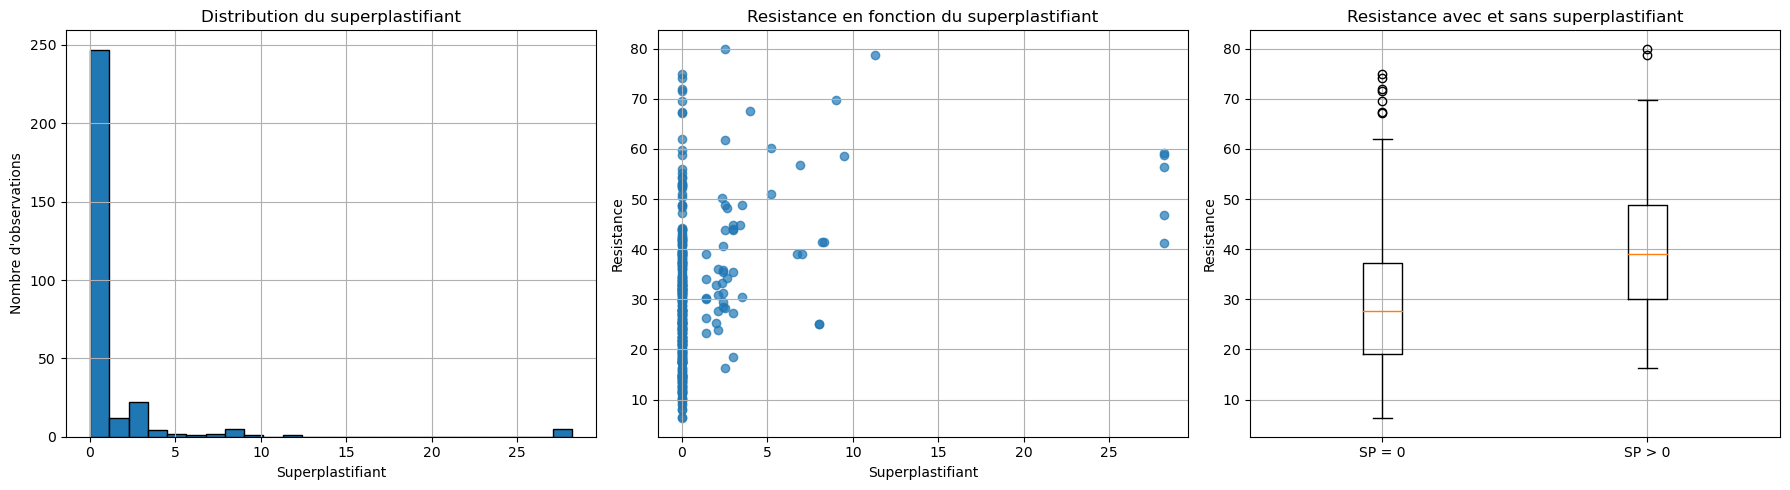

Résistance moyenne sans superplastifiant : 29.370295546558705
Résistance moyenne avec superplastifiant : 41.0991090909091


In [16]:
if "Superplastifiant" in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(df["Superplastifiant"].dropna(), bins=25, edgecolor="black")
    axes[0].set_title("Distribution du superplastifiant")
    axes[0].set_xlabel("Superplastifiant")
    axes[0].set_ylabel("Nombre d'observations")

    axes[1].scatter(df["Superplastifiant"], df["Resistance"], alpha=0.7)
    axes[1].set_title("Resistance en fonction du superplastifiant")
    axes[1].set_xlabel("Superplastifiant")
    axes[1].set_ylabel("Resistance")

    # Comparaison simple : formulations avec et sans superplastifiant, sans créer de nouvelle colonne
    without_sp = df.loc[df["Superplastifiant"] == 0, "Resistance"]
    with_sp = df.loc[df["Superplastifiant"] > 0, "Resistance"]

    axes[2].boxplot([without_sp.dropna(), with_sp.dropna()], labels=["SP = 0", "SP > 0"])
    axes[2].set_title("Resistance avec et sans superplastifiant")
    axes[2].set_ylabel("Resistance")

    plt.tight_layout()
    plt.show()

    print("Résistance moyenne sans superplastifiant :", without_sp.mean())
    print("Résistance moyenne avec superplastifiant :", with_sp.mean())

## 16. Analyse des granulats

### Question métier

**Comment les granulats influencent-ils la résistance ?**

Les granulats occupent une grande partie du volume du béton.  
Ils influencent :

- la compacité ;
- la maniabilité ;
- la résistance mécanique ;
- la stabilité du squelette granulaire.

Le rapport `G/S`, déjà présent dans le fichier, donne une indication sur l'équilibre entre granulats grossiers et granulats fins.

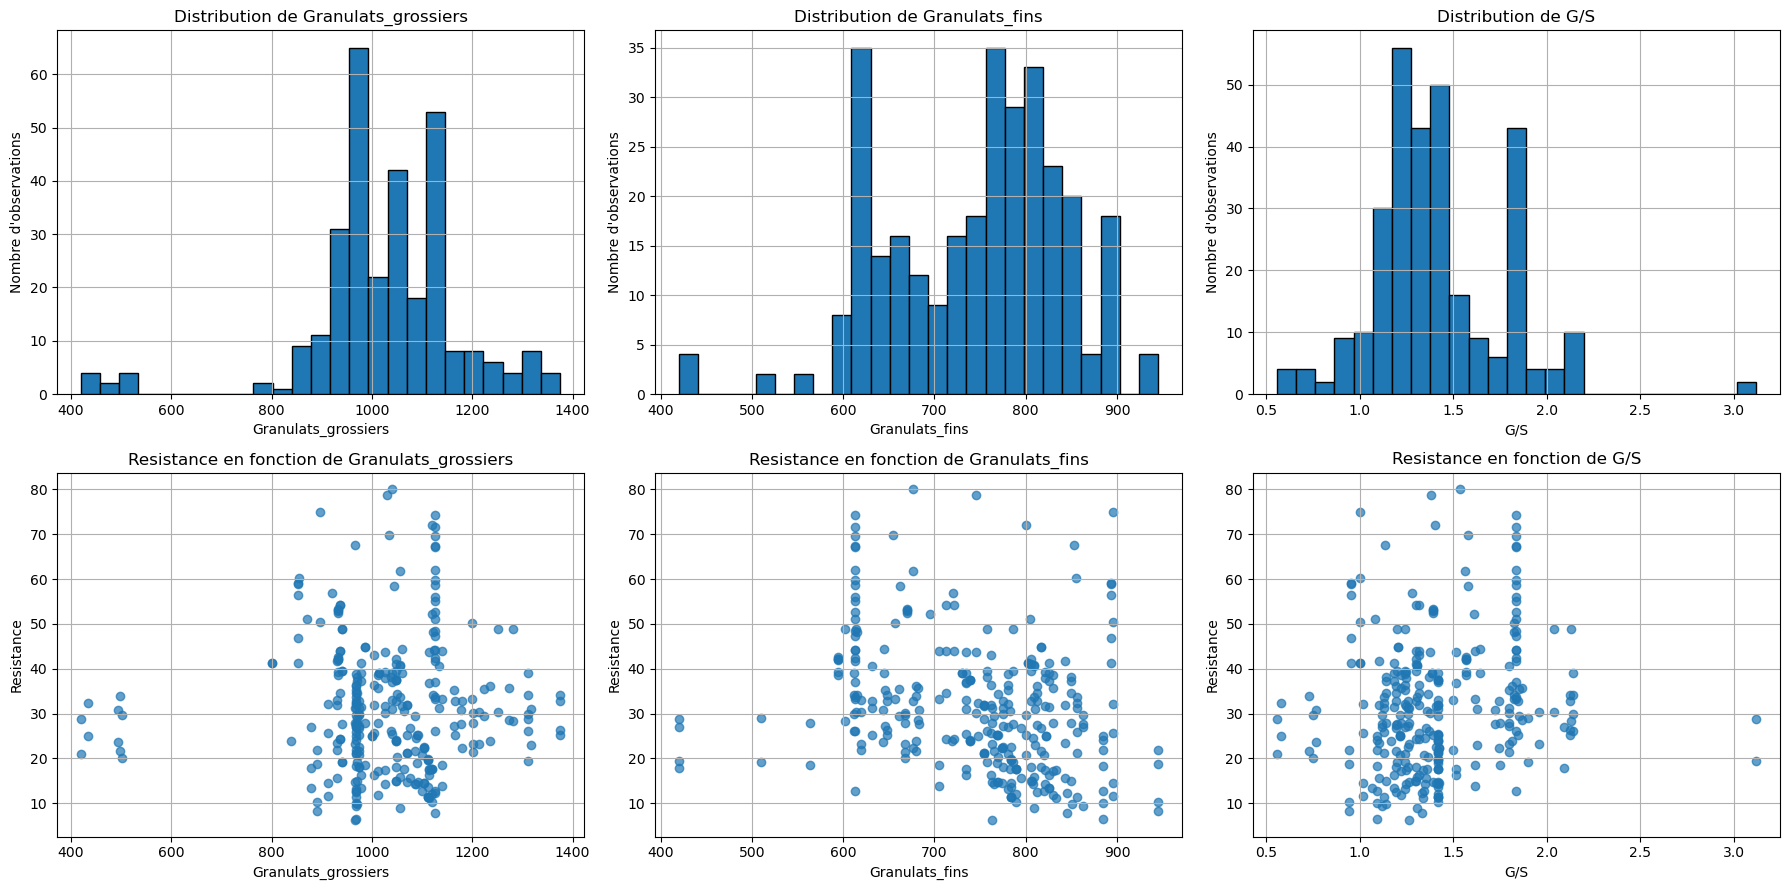

In [17]:
gran_cols = [col for col in ["Granulats_grossiers", "Granulats_fins", "G/S"] if col in df.columns]

fig, axes = plt.subplots(2, len(gran_cols), figsize=(6 * len(gran_cols), 9))
if len(gran_cols) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for i, col in enumerate(gran_cols):
    axes[0, i].hist(df[col].dropna(), bins=25, edgecolor="black")
    axes[0, i].set_title(f"Distribution de {col}")
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel("Nombre d'observations")

    axes[1, i].scatter(df[col], df["Resistance"], alpha=0.7)
    axes[1, i].set_title(f"Resistance en fonction de {col}")
    axes[1, i].set_xlabel(col)
    axes[1, i].set_ylabel("Resistance")

plt.tight_layout()
plt.show()

## 17. Analyse comparative des niveaux de résistance

### Utilité dans le projet

Sans créer de nouvelle colonne, on peut examiner les formulations les plus faibles et les plus résistantes.

Cette comparaison aide à comprendre :

- quels dosages apparaissent dans les bétons les plus résistants ;
- quels dosages apparaissent dans les bétons les moins résistants ;
- quelles tendances pourront être exploitées plus tard par les modèles de prédiction.

10 formulations avec les plus faibles résistances :


,Ciment,Eau,Superplastifiant,Granulats_grossiers,Granulats_fins,G/S,E/C,Age,Resistance
160,385.0,186.0,0.0,966.0,763.0,1.266,0.483,1,6.27
78,236.0,194.0,0.0,968.0,885.0,1.094,0.822,3,6.47
100,200.0,180.0,0.0,1125.0,845.0,1.331,0.900,7,7.84
56,255.0,192.0,0.0,889.8,945.0,0.942,0.753,3,8.20
129,349.0,192.0,0.0,1056.0,809.0,1.305,0.550,7,9.01
90,254.0,198.0,0.0,968.0,863.0,1.122,0.780,3,9.31
13,310.0,192.0,0.0,971.0,850.6,1.142,0.619,3,9.87
99,236.0,193.0,0.0,968.0,885.0,1.094,0.818,7,9.99
48,255.0,192.0,0.0,889.8,945.0,0.942,0.753,7,10.22
67,238.1,185.7,0.0,1118.8,789.3,1.417,0.780,7,10.34


10 formulations avec les plus fortes résistances :


,Ciment,Eau,Superplastifiant,Granulats_grossiers,Granulats_fins,G/S,E/C,Age,Resistance
150,540.0,173.0,0.0,1125.0,613.0,1.835,0.320,28,67.31
25,500.0,140.0,4.0,966.0,853.0,1.132,0.280,28,67.57
151,540.0,173.0,0.0,1125.0,613.0,1.835,0.320,90,69.66
35,500.0,151.0,9.0,1033.0,655.0,1.577,0.302,28,69.84
152,540.0,173.0,0.0,1125.0,613.0,1.835,0.320,180,71.62
14,485.0,146.0,0.0,1120.0,800.0,1.400,0.301,28,71.99
153,540.0,173.0,0.0,1125.0,613.0,1.835,0.320,270,74.17
225,522.0,146.0,0.0,896.0,896.0,1.000,0.280,28,74.99
26,451.0,165.0,11.3,1030.0,745.0,1.383,0.366,28,78.80
0,540.0,162.0,2.5,1040.0,676.0,1.538,0.300,28,79.99


,Moyenne_10_plus_faibles,Moyenne_10_plus_fortes
Ciment,271.810,515.800
Eau,190.470,160.200
Superplastifiant,0.000,2.680
Granulats_grossiers,992.040,1058.500
Granulats_fins,857.990,707.700
G/S,1.165,1.537
E/C,0.726,0.311
Age,4.800,73.600
Resistance,8.752,72.594


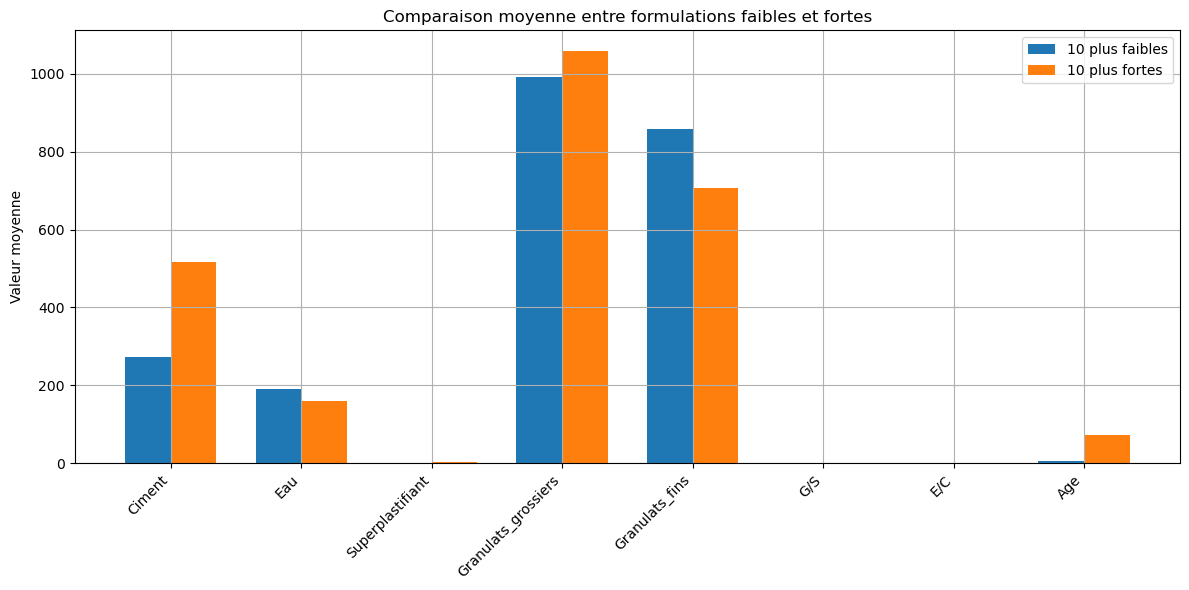

In [18]:
if "Resistance" in df.columns:
    df_sorted = df.sort_values("Resistance")

    faibles = df_sorted.head(10)
    fortes = df_sorted.tail(10)

    print("10 formulations avec les plus faibles résistances :")
    display(faibles)

    print("10 formulations avec les plus fortes résistances :")
    display(fortes)

    mean_compare = pd.DataFrame({
        "Moyenne_10_plus_faibles": faibles[numeric_cols].mean(),
        "Moyenne_10_plus_fortes": fortes[numeric_cols].mean()
    })

    display(mean_compare)

    # Graphique comparatif des moyennes
    plot_data = mean_compare.drop(index=["Resistance"], errors="ignore")

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(plot_data.index))
    width = 0.35

    ax.bar(x - width/2, plot_data["Moyenne_10_plus_faibles"], width, label="10 plus faibles")
    ax.bar(x + width/2, plot_data["Moyenne_10_plus_fortes"], width, label="10 plus fortes")

    ax.set_xticks(x)
    ax.set_xticklabels(plot_data.index, rotation=45, ha="right")
    ax.set_title("Comparaison moyenne entre formulations faibles et fortes")
    ax.set_ylabel("Valeur moyenne")
    ax.legend()

    plt.tight_layout()
    plt.show()

## 18. Analyse de la couverture du domaine de formulation

### Question métier

**Le dataset couvre-t-il suffisamment l'espace des formulations ?**

Pour entraîner un modèle fiable, il faut que le dataset contienne des formulations variées.

Si toutes les formulations sont très proches, le modèle ne saura pas généraliser.  
S'il existe plusieurs plages de ciment, d'eau, de granulats, d'âge et de résistance, le modèle aura plus d'informations pour apprendre.

Cette section observe les relations entre composants principaux.

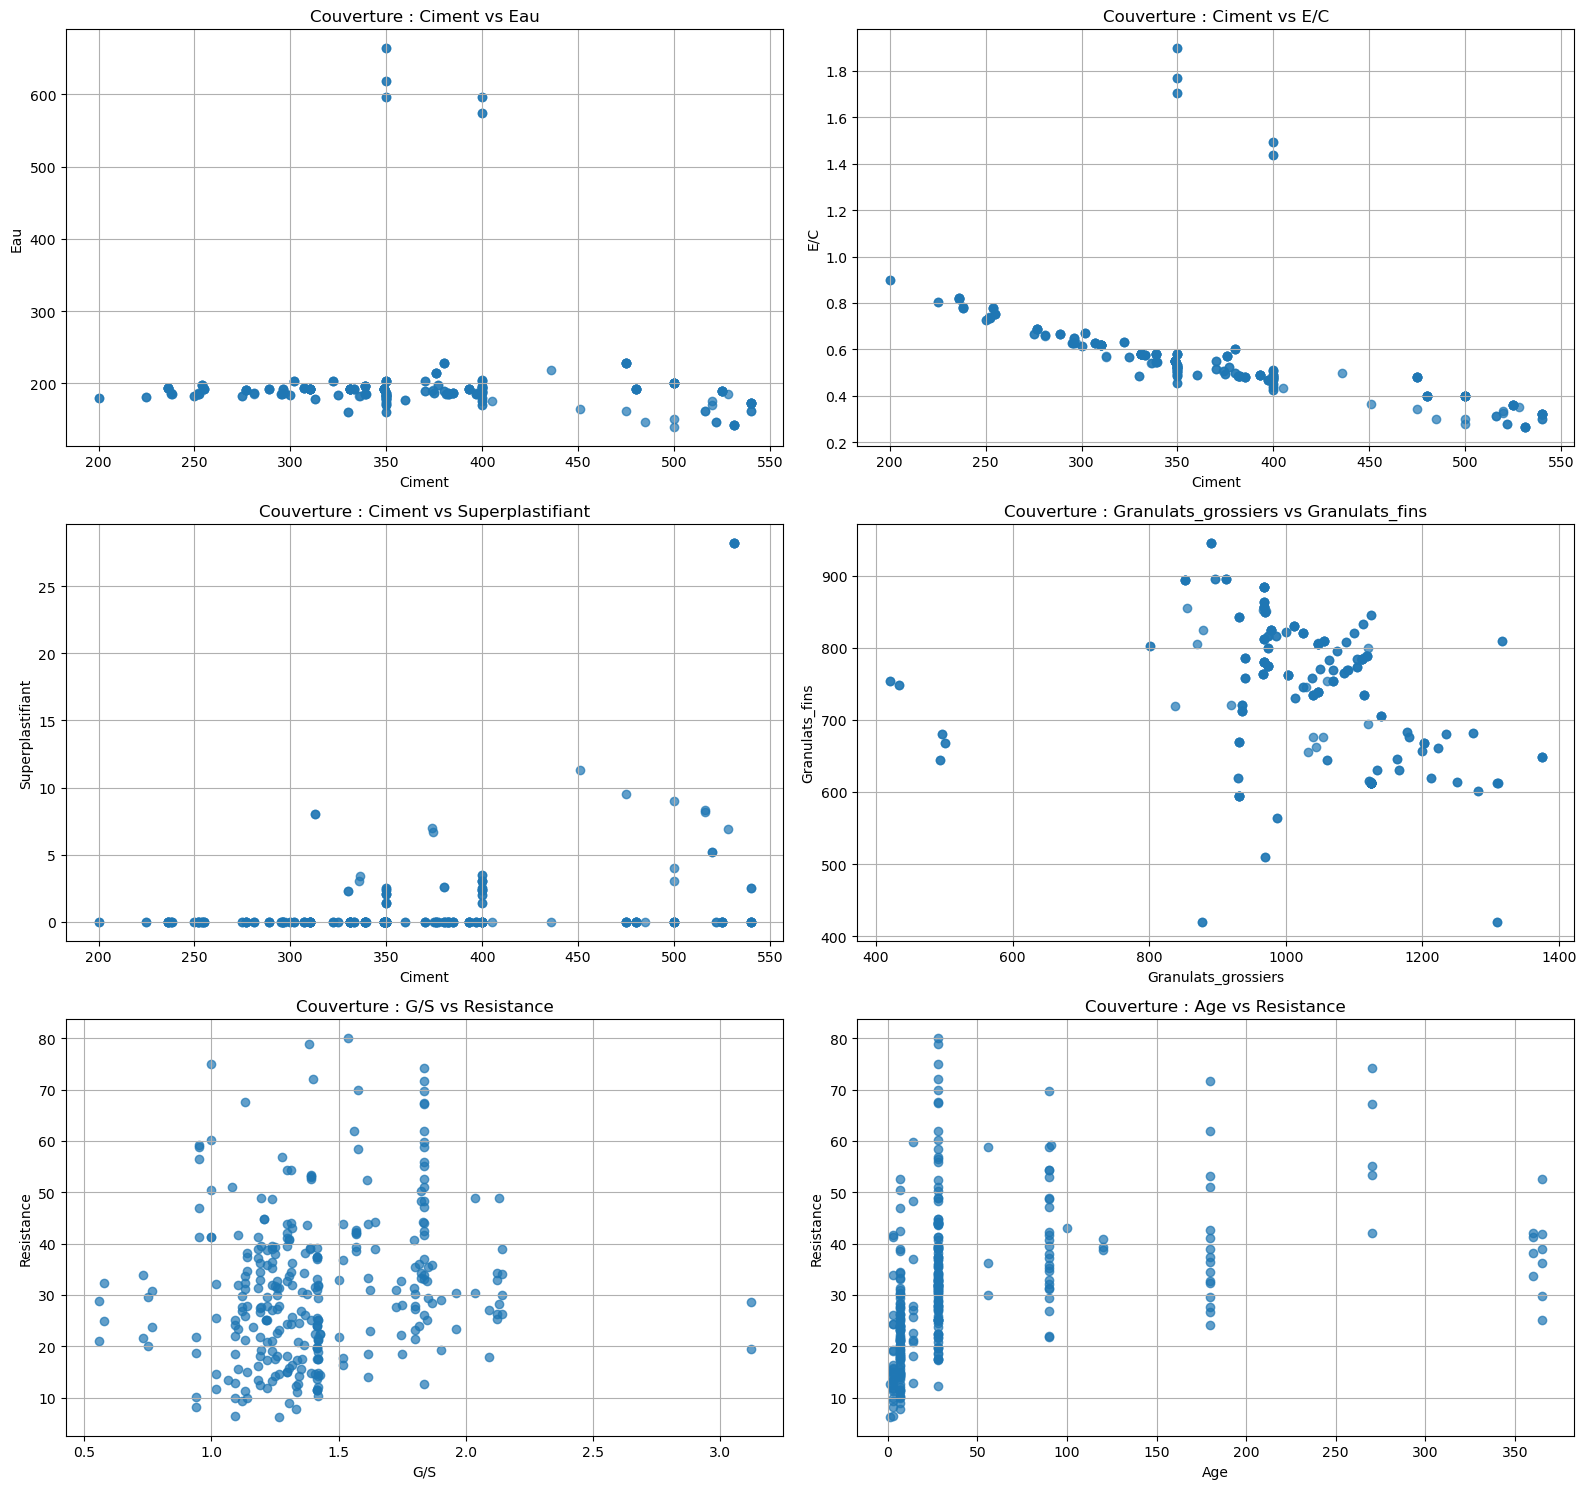

In [19]:
pairs = [
    ("Ciment", "Eau"),
    ("Ciment", "E/C"),
    ("Ciment", "Superplastifiant"),
    ("Granulats_grossiers", "Granulats_fins"),
    ("G/S", "Resistance"),
    ("Age", "Resistance")
]

available_pairs = [(x, y) for x, y in pairs if x in df.columns and y in df.columns]

n_cols = 2
n_rows = int(np.ceil(len(available_pairs) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, (x, y) in enumerate(available_pairs):
    axes[i].scatter(df[x], df[y], alpha=0.7)
    axes[i].set_title(f"Couverture : {x} vs {y}")
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 19. Synthèse statistique orientée génie civil

### Utilité dans le projet

Cette synthèse prépare directement le notebook suivant consacré à la modélisation.

Elle permet de répondre aux questions suivantes :

1. Quelles variables semblent les plus liées à la résistance ?
2. Le dataset contient-il suffisamment de diversité ?
3. Certaines variables devront-elles être surveillées avant l'apprentissage ?
4. Les tendances observées sont-elles cohérentes avec le comportement physique du béton ?

Variables les plus corrélées avec la résistance, en valeur absolue :


,Corrélation avec Resistance
Ciment,0.703
E/C,-0.409
Age,0.352
Superplastifiant,0.309
Granulats_fins,-0.279
G/S,0.167
Eau,-0.108
Granulats_grossiers,0.015



Résumé de la résistance :
Résistance minimale : 6.27
Résistance moyenne : 31.506337748344368
Résistance maximale : 79.99
Écart-type : 14.615581539099933


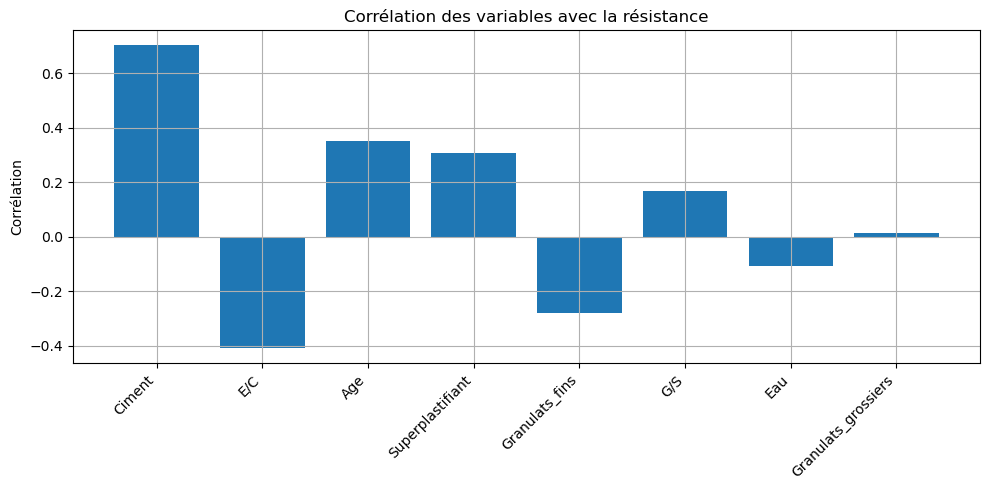

In [20]:
if "Resistance" in df.columns:
    corr_res = df[numeric_cols].corr()["Resistance"].drop("Resistance").sort_values(key=lambda s: s.abs(), ascending=False)
    print("Variables les plus corrélées avec la résistance, en valeur absolue :")
    display(corr_res.to_frame("Corrélation avec Resistance"))

    print("\nRésumé de la résistance :")
    print("Résistance minimale :", df["Resistance"].min())
    print("Résistance moyenne :", df["Resistance"].mean())
    print("Résistance maximale :", df["Resistance"].max())
    print("Écart-type :", df["Resistance"].std())

    plt.figure(figsize=(10, 5))
    plt.bar(corr_res.index, corr_res.values)
    plt.xticks(rotation=45, ha="right")
    plt.title("Corrélation des variables avec la résistance")
    plt.ylabel("Corrélation")
    plt.tight_layout()
    plt.show()

## 20. Conclusions métier de l'EDA

### Ce que l'EDA apporte au projet

Cette étude exploratoire permet de mieux comprendre le dataset avant la modélisation.

#### 1. Compréhension des formulations

On a observé les plages de valeurs des composants :

- ciment ;
- eau ;
- superplastifiant ;
- granulats ;
- âge ;
- résistance.

Cela permet de vérifier que les formulations sont physiquement interprétables.

#### 2. Identification des variables importantes

Les graphiques et la matrice de corrélation permettent d'identifier les variables qui semblent les plus liées à la résistance.

Ces variables seront utilisées dans le notebook suivant pour construire les modèles de Machine Learning.

#### 3. Détection des valeurs atypiques

Les boxplots mettent en évidence les valeurs extrêmes.  
Ces valeurs devront être surveillées car elles peuvent influencer l'entraînement.

#### 4. Préparation à la prédiction

Après cette EDA, on pourra passer à la question suivante :

> À partir d'une composition donnée, peut-on prédire correctement la résistance du béton ?

Cette question sera traitée dans le notebook 2 consacré à la modélisation.

#### 5. Préparation à la formulation inverse

Plus tard, on pourra aussi traiter une question métier inverse :

> Si un client demande une résistance donnée, quelle composition peut-on proposer ?

Mais cette question ne sera pas traitée dans ce  EDA.  
Elle sera étudiée dans la partie Machine Learning / optimisation.